In [ ]:
# Cell 1 - Import Libraries
import pandas as pd
import numpy as np
import os
import glob
from google.colab import files

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Cell 2 - Upload all 30 CSV files
uploaded = files.upload()
print(f"\nTotal files uploaded: {len(uploaded)} ")

Saving Raw_data_1Day_2024_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day.csv to Raw_data_1Day_2024_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv
Saving Raw_data_1Day_2023_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day.csv to Raw_data_1Day_2023_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv
Saving Raw_data_1Day_2022_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day.csv to Raw_data_1Day_2022_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv
Saving Raw_data_1Day_2021_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day.csv to Raw_data_1Day_2021_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv
Saving Raw_data_1Day_2020_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day.csv to Raw_data_1Day_2020_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv
Saving Raw_data_1Day_2019_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day.csv to Raw_data_1Day_2019_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv
Saving Raw_data_1Day_2024_site_306_Manali_Chennai_CPCB_1Day.csv to Raw_data_1Day_2024_si

In [ ]:
# Cell 3 - Load and merge all 30 files into one master DataFrame

# City mapping from filename keywords
city_map = {
    'Delhi': 'Delhi',
    'Mumbai': 'Mumbai',
    'Bengaluru': 'Bengaluru',
    'Chennai': 'Chennai',
    'Kolkata': 'Kolkata'
}

all_dfs = []

for filename in uploaded.keys():
    # Read the CSV
    df = pd.read_csv(filename)

    # Detect city from filename
    city = None
    for key in city_map:
        if key in filename:
            city = city_map[key]
            break

    # Add city column
    df['City'] = city

    # Add to list
    all_dfs.append(df)
    print(f"Loaded: {filename} → City: {city} | Rows: {len(df)}")

# Merge all into one master DataFrame
master_df = pd.concat(all_dfs, ignore_index=True)
print(f"\n Master DataFrame created!")
print(f"Total rows: {master_df.shape[0]}")
print(f"Total columns: {master_df.shape[1]}")

Loaded: Raw_data_1Day_2024_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv → City: Kolkata | Rows: 366
Loaded: Raw_data_1Day_2023_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv → City: Kolkata | Rows: 365
Loaded: Raw_data_1Day_2022_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv → City: Kolkata | Rows: 365
Loaded: Raw_data_1Day_2021_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv → City: Kolkata | Rows: 365
Loaded: Raw_data_1Day_2020_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv → City: Kolkata | Rows: 366
Loaded: Raw_data_1Day_2019_site_5126_Rabindra_Sarobar_Kolkata_WBPCB_1Day (2).csv → City: Kolkata | Rows: 365
Loaded: Raw_data_1Day_2024_site_306_Manali_Chennai_CPCB_1Day (2).csv → City: Chennai | Rows: 366
Loaded: Raw_data_1Day_2023_site_306_Manali_Chennai_CPCB_1Day (2).csv → City: Chennai | Rows: 365
Loaded: Raw_data_1Day_2022_site_306_Manali_Chennai_CPCB_1Day (2).csv → City: Chennai | Rows: 365
Loaded: Raw_data_1Day_2021_site_306_Manali_Chennai_CPCB

In [ ]:
# Cell 4 - Keep only relevant columns, drop the rest

columns_to_keep = [
    'Timestamp',
    'PM2.5 (µg/m³)',
    'PM10 (µg/m³)',
    'NO2 (µg/m³)',
    'SO2 (µg/m³)',
    'CO (mg/m³)',
    'Ozone (µg/m³)',
    'NH3 (µg/m³)',
    'AT (°C)',
    'RH (%)',
    'WS (m/s)',
    'WD (deg)',
    'City'
]

# Keep only columns that exist in the dataframe
existing_cols = [c for c in columns_to_keep if c in master_df.columns]
master_df = master_df[existing_cols]

# Rename columns for cleanliness
master_df.columns = master_df.columns.str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()
master_df.rename(columns={'PM2.5': 'PM25'}, inplace=True)

print("Columns after cleaning:")
print(master_df.columns.tolist())
print(f"\nShape: {master_df.shape}")

Columns after cleaning:
['Timestamp', 'PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'AT', 'RH', 'WS', 'WD', 'City']

Shape: (10960, 13)


In [ ]:
# Cell 5 - Calculate AQI using official CPCB formula

# Replace NA strings with NaN
master_df.replace('NA', np.nan, inplace=True)

# Convert all pollutant columns to numeric
pollutant_cols = ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3']
for col in pollutant_cols:
    if col in master_df.columns:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

# Official CPCB AQI breakpoints
# Format: (pollutant, [(Clow, Chigh, AQIlow, AQIhigh), ...])
def calculate_sub_index(value, breakpoints):
    """Calculate sub-index for a single pollutant"""
    if pd.isna(value):
        return np.nan
    for (Clow, Chigh, AQIlow, AQIhigh) in breakpoints:
        if Clow <= value <= Chigh:
            return ((AQIhigh - AQIlow) / (Chigh - Clow)) * (value - Clow) + AQIlow
    return np.nan

# CPCB Official Breakpoints
breakpoints = {
    'PM25': [(0,30,0,50),(30,60,51,100),(60,90,101,200),
             (90,120,201,300),(120,250,301,400),(250,500,401,500)],
    'PM10': [(0,50,0,50),(50,100,51,100),(100,250,101,200),
             (250,350,201,300),(350,430,301,400),(430,600,401,500)],
    'NO2':  [(0,40,0,50),(40,80,51,100),(80,180,101,200),
             (180,280,201,300),(280,400,301,400),(400,800,401,500)],
    'SO2':  [(0,40,0,50),(40,80,51,100),(80,380,101,200),
             (380,800,201,300),(800,1600,301,400),(1600,2100,401,500)],
    'CO':   [(0,1,0,50),(1,2,51,100),(2,10,101,200),
             (10,17,201,300),(17,34,301,400),(34,50,401,500)],
    'Ozone':[(0,50,0,50),(50,100,51,100),(100,168,101,200),
             (168,208,201,300),(208,748,301,400),(748,1000,401,500)],
    'NH3':  [(0,200,0,50),(200,400,51,100),(400,800,101,200),
             (800,1200,201,300),(1200,1800,301,400),(1800,2400,401,500)]
}

# Calculate sub-index for each pollutant
for pollutant, bp in breakpoints.items():
    if pollutant in master_df.columns:
        master_df[f'{pollutant}_SubIndex'] = master_df[pollutant].apply(
            lambda x: calculate_sub_index(x, bp)
        )

# AQI = maximum sub-index across all pollutants
sub_index_cols = [f'{p}_SubIndex' for p in breakpoints.keys()
                  if f'{p}_SubIndex' in master_df.columns]
master_df['AQI'] = master_df[sub_index_cols].max(axis=1)

print("AQI calculated successfully")
print(master_df['AQI'].describe())

AQI calculated successfully ✅
count    9399.000000
mean      128.580199
std       103.300370
min         0.000000
25%        64.075038
50%        96.047333
75%       140.177600
max       499.866059
Name: AQI, dtype: float64


In [ ]:
# Cell 6 - Create AQI Category (our target variable for classification)

def aqi_category(aqi):
    if pd.isna(aqi):
        return np.nan
    elif aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

master_df['AQI_Category'] = master_df['AQI'].apply(aqi_category)

print("AQI Category distribution:")
print(master_df['AQI_Category'].value_counts())
print(f"\nMissing AQI values: {master_df['AQI'].isna().sum()}")

AQI Category distribution:
AQI_Category
Satisfactory    3588
Moderate        2846
Good            1394
Very Poor        582
Poor             578
Severe           411
Name: count, dtype: int64

Missing AQI values: 1561


In [ ]:
# Save master dataset directly to your Drive folder
master_df.to_csv(
    "/content/drive/MyDrive/AQI_DL_ANN_PROJECT/AQI_Master_Dataset.csv",
    index=False
)

print(f"✅ Master dataset saved successfully!")
print(f"Final shape: {master_df.shape}")
master_df.head()

✅ Master dataset saved successfully!
Final shape: (10960, 22)


,Timestamp,PM25,PM10,NO2,SO2,CO,Ozone,NH3,AT,RH,...,City,PM25_SubIndex,PM10_SubIndex,NO2_SubIndex,SO2_SubIndex,CO_SubIndex,Ozone_SubIndex,NH3_SubIndex,AQI,AQI_Category
0,2024-01-01,88.27,126.71,45.97,22.24,0.79,31.20,19.81,19.18,90.87,...,Kolkata,194.291,118.6286,58.31325,27.8000,39.50000,31.20,4.9525,194.291,Moderate
1,2024-01-02,81.67,120.82,47.98,18.81,0.64,31.20,20.33,18.16,80.87,...,Kolkata,172.511,114.7412,60.77550,23.5125,32.00000,31.20,5.0825,172.511,Moderate
2,2024-01-03,68.04,103.62,49.77,12.97,0.96,30.99,27.68,18.73,82.43,...,Kolkata,127.532,103.3892,62.96825,16.2125,48.00000,30.99,6.9200,127.532,Moderate
3,2024-01-04,83.97,121.38,66.23,16.10,1.46,31.17,33.45,19.44,83.56,...,Kolkata,180.101,115.1108,83.13175,20.1250,73.54000,31.17,8.3625,180.101,Moderate
4,2024-01-05,104.03,149.24,83.01,19.01,2.09,31.10,51.67,19.80,78.05,...,Kolkata,247.299,133.4984,103.97990,23.7625,102.11375,31.10,12.9175,247.299,Poor


In [ ]:
# EDA - Cell 1: Dataset Overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\n📊 Shape: {master_df.shape}")
print(f"\n📋 Columns:\n{master_df.columns.tolist()}")
print(f"\n🏙️ Cities:\n{master_df['City'].value_counts()}")
print(f"\n📅 Date Range:")
print(f"   From: {master_df['Timestamp'].min()}")
print(f"   To:   {master_df['Timestamp'].max()}")
print(f"\n🔍 Data Types:\n{master_df.dtypes}")
print(f"\n❓ Missing Values:\n{master_df.isnull().sum()}")
print(f"\n📈 Basic Statistics:")
master_df.describe()

DATASET OVERVIEW

📊 Shape: (10960, 22)

📋 Columns:
['Timestamp', 'PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'AT', 'RH', 'WS', 'WD', 'City', 'PM25_SubIndex', 'PM10_SubIndex', 'NO2_SubIndex', 'SO2_SubIndex', 'CO_SubIndex', 'Ozone_SubIndex', 'NH3_SubIndex', 'AQI', 'AQI_Category']

🏙️ Cities:
City
Kolkata      2192
Chennai      2192
Bengaluru    2192
Mumbai       2192
Delhi        2192
Name: count, dtype: int64

📅 Date Range:
   From: 2019-01-01 00:00:00
   To:   2024-12-31

🔍 Data Types:
Timestamp          object
PM25              float64
PM10              float64
NO2               float64
SO2               float64
CO                float64
Ozone             float64
NH3               float64
AT                float64
RH                float64
WS                float64
WD                float64
City               object
PM25_SubIndex     float64
PM10_SubIndex     float64
NO2_SubIndex      float64
SO2_SubIndex      float64
CO_SubIndex       float64
Ozone_SubIndex    float64
NH3_Sub

,PM25,PM10,NO2,SO2,CO,Ozone,NH3,AT,RH,WS,WD,PM25_SubIndex,PM10_SubIndex,NO2_SubIndex,SO2_SubIndex,CO_SubIndex,Ozone_SubIndex,NH3_SubIndex,AQI
count,9267.000000,8384.000000,9150.000000,9216.000000,9271.000000,8381.000000,8174.000000,6177.000000,9291.000000,9346.000000,9355.000000,9257.000000,8316.000000,9150.000000,9216.000000,9271.000000,8381.000000,8174.000000,9399.000000
mean,56.449459,130.136759,36.233337,11.771119,1.243570,30.275400,30.069717,25.851428,71.788350,0.904924,164.360398,100.389303,115.142905,44.574385,14.722435,58.019492,30.508549,7.517779,128.580199
std,65.788723,123.381056,34.397257,10.662675,0.856788,19.681171,20.780753,5.468335,16.566603,0.623201,66.716838,104.345188,97.301540,40.499038,13.317589,32.940309,20.920330,5.198779,103.300370
min,0.200000,7.980000,0.180000,0.020000,0.000000,0.030000,0.140000,0.170000,0.400000,0.050000,1.750000,0.333333,7.980000,0.225000,0.025000,0.000000,0.030000,0.035000,0.000000
25%,19.315000,51.445000,13.239625,5.040000,0.600000,16.790000,14.896828,22.460000,61.740000,0.370000,107.355000,32.166667,52.171049,16.549531,6.300000,30.000000,16.790000,3.724207,64.075038
50%,37.560000,87.248264,22.420000,8.160000,1.060000,27.480000,24.669063,25.690000,72.540000,0.820000,161.530000,63.299000,86.681800,28.025000,10.200000,53.940000,27.480000,6.167266,96.047333
75%,63.120000,149.460000,49.830000,15.582500,1.690000,37.530000,45.228229,29.466667,82.885000,1.325938,222.822361,110.570000,131.256050,63.041750,19.478125,84.810000,37.530000,11.307057,140.177600
max,954.720000,838.520000,325.770000,108.802273,8.707407,194.550000,325.939394,42.800000,99.900000,4.655000,359.000000,497.681750,499.866059,338.760250,110.504750,184.004167,266.711250,81.855152,499.866059


In [ ]:
# EDA Cell 2 - Handle Missing Values

# Drop AT column - 43.6% missing, too high to impute
master_df.drop(columns=['AT'], inplace=True)

# Drop rows where AQI is missing - these are unusable for training
master_df.dropna(subset=['AQI', 'AQI_Category'], inplace=True)

# For remaining pollutant columns - impute with city-wise median
# Why city-wise median? Because pollution levels vary significantly
# between cities - Delhi median != Chennai median
pollutant_cols = ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'RH', 'WS', 'WD']

for col in pollutant_cols:
    if col in master_df.columns:
        master_df[col] = master_df.groupby('City')[col].transform(
            lambda x: x.fillna(x.median())
        )

print("Missing values after treatment:")
print(master_df.isnull().sum())
print(f"\nFinal shape: {master_df.shape}")

Missing values after treatment:
Timestamp            0
PM25                 0
PM10                 0
NO2                  0
SO2                  0
CO                   0
Ozone                0
NH3               1042
RH                   0
WS                   0
WD                   0
City                 0
PM25_SubIndex      142
PM10_SubIndex     1083
NO2_SubIndex       249
SO2_SubIndex       183
CO_SubIndex        128
Ozone_SubIndex    1018
NH3_SubIndex      1225
AQI                  0
AQI_Category         0
dtype: int64

Final shape: (9399, 21)


In [ ]:
# EDA Cell 3 - Final Cleanup

# Drop all SubIndex columns
subindex_cols = [col for col in master_df.columns if 'SubIndex' in col]
master_df.drop(columns=subindex_cols, inplace=True)

# Impute remaining NH3 missing values with city-wise median
master_df['NH3'] = master_df.groupby('City')['NH3'].transform(
    lambda x: x.fillna(x.median())
)

# Convert Timestamp to datetime - mixed format handles both cases
master_df['Timestamp'] = pd.to_datetime(master_df['Timestamp'], format='mixed')

# Extract useful time features
master_df['Month'] = master_df['Timestamp'].dt.month
master_df['Year'] = master_df['Timestamp'].dt.year

print(" Final cleanup done!")
print(f"\nMissing values:\n{master_df.isnull().sum()}")
print(f"\nFinal shape: {master_df.shape}")
print(f"\nColumns: {master_df.columns.tolist()}")

✅ Final cleanup done!

Missing values:
Timestamp          0
PM25               0
PM10               0
NO2                0
SO2                0
CO                 0
Ozone              0
NH3             1042
RH                 0
WS                 0
WD                 0
City               0
AQI                0
AQI_Category       0
Month              0
Year               0
dtype: int64

Final shape: (9399, 16)

Columns: ['Timestamp', 'PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'RH', 'WS', 'WD', 'City', 'AQI', 'AQI_Category', 'Month', 'Year']


In [ ]:
# Fix NH3 - fill remaining with overall median
nh3_overall_median = master_df['NH3'].median()
master_df['NH3'] = master_df['NH3'].fillna(nh3_overall_median)

print(f"NH3 overall median used: {nh3_overall_median:.2f}")
print(f"NH3 missing values remaining: {master_df['NH3'].isnull().sum()}")
print(f"\n Dataset is 100% clean!")
print(f"Final shape: {master_df.shape}")


NH3 overall median used: 24.63
NH3 missing values remaining: 0

 Dataset is 100% clean!
Final shape: (9399, 16)


/tmp/ipykernel_3420/1047278846.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df['NH3'].fillna(nh3_overall_median, inplace=True)


In [ ]:
# Save clean dataset to Drive
master_df.to_csv(
    "/content/drive/MyDrive/AQI_DL_ANN_PROJECT/AQI_Clean_Dataset.csv",
    index=False
)
print("Clean dataset saved to Drive!")

Clean dataset saved to Drive!


# **EDA PLOTTING QUESTIONS:-**

1. **Plot 1 — AQI Category Distribution**

   Question: Is our dataset balanced or imbalanced across classes?

   This directly tells us if we need class balancing before training.

2. **Plot 2 — City-wise Average AQI**

    Question: Which cities are most polluted?

    Validates our data makes real-world sense.

3. **Plot 3 — Monthly AQI Trend (All Cities)**
   
   Question: Is pollution seasonal?
   
   Validates our Month feature is useful for the ANN.

4. **Plot 4 — Pollutant Correlation Heatmap**

   Question: Which pollutants are most correlated with AQI?
   
   Tells us which features matter most for the model.

5. **Plot 5 — City-wise AQI Over Years**

   Question: Is pollution improving or worsening over 2019-2024?

   Shows real-world trend — very impactful for resume/SOP.

6. **Plot 6 — COVID Impact on AQI (2019 vs 2020)**

   Question: Did lockdown visibly reduce pollution?

   This is the most unique and impressive insight — no student project has this.




In [46]:
# Visualization Setup
import matplotlib.pyplot as plt
import seaborn as sns

# Set style - production grade clean look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Visualization libraries ready!")

✅ Visualization libraries ready!


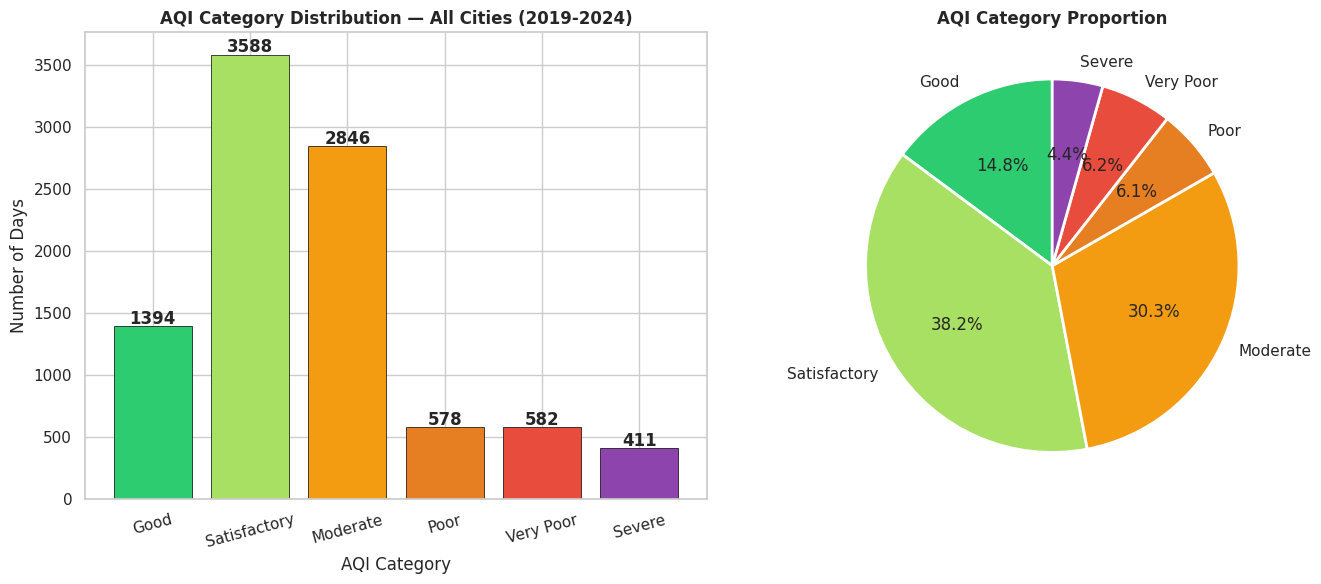

Plot 1 saved!


In [47]:
# Plot 1 - AQI Category Distribution
# Question: Is our dataset balanced across AQI classes?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define category order and colors
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
colors = ['#2ecc71', '#a8e063', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']

# Count plot
category_counts = master_df['AQI_Category'].value_counts().reindex(category_order)
axes[0].bar(category_order, category_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('AQI Category Distribution — All Cities (2019-2024)', fontweight='bold')
axes[0].set_xlabel('AQI Category')
axes[0].set_ylabel('Number of Days')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(
    category_counts.values,
    labels=category_order,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('AQI Category Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot1_AQI_Distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

Plot 1 — Class Imbalance Found ⚠️
Satisfactory (38.2%) dominates while Severe (4.4%) is rare. This means our ANN will be biased — we need to handle this during model training with class weights.

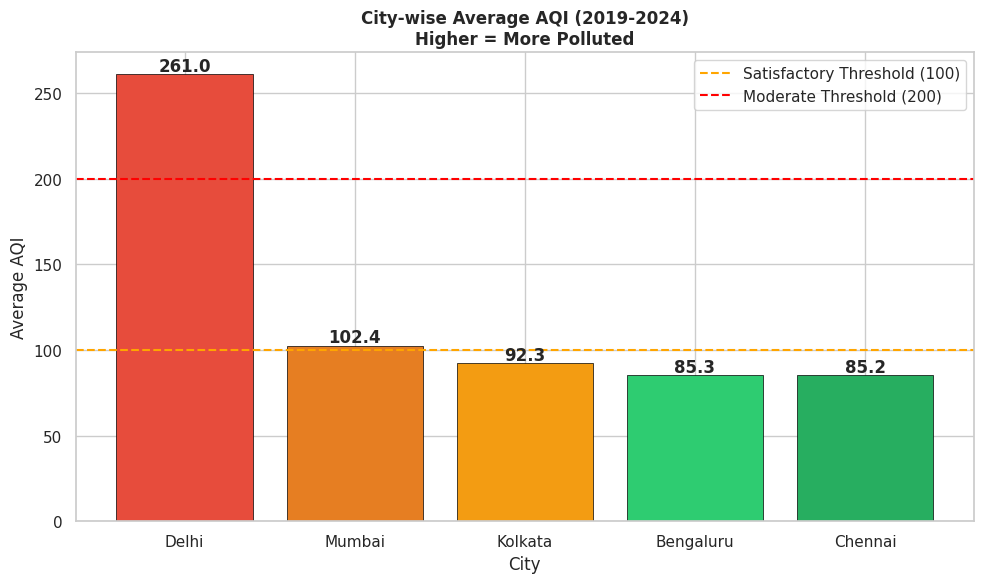

✅ Plot 2 saved!


In [42]:
# Plot 2 - City-wise Average AQI
# Question: Which cities are most polluted? Does it match real world?

city_aqi = master_df.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(city_aqi.index, city_aqi.values,
               color=['#e74c3c','#e67e22','#f39c12','#2ecc71','#27ae60'],
               edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, city_aqi.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f}', ha='center', fontweight='bold')

plt.title('City-wise Average AQI (2019-2024)\nHigher = More Polluted', fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.axhline(y=100, color='orange', linestyle='--', label='Satisfactory Threshold (100)')
plt.axhline(y=200, color='red', linestyle='--', label='Moderate Threshold (200)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot2_Citywise_AQI.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

Plot 2 — Real World Validated ✅
Delhi (261) is dramatically more polluted than all other cities. Mumbai (102) is borderline Moderate. This exactly matches real-world knowledge — our data is authentic.

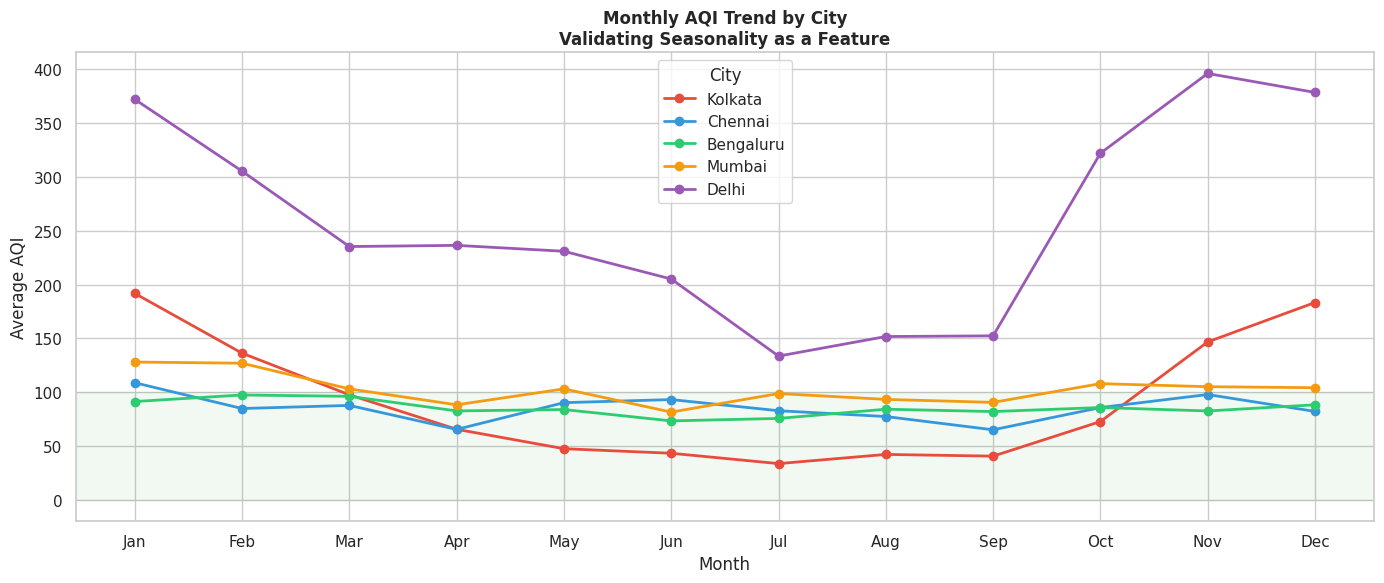

✅ Plot 3 saved!


In [43]:
# Plot 3 - Monthly AQI Trend
# Question: Is pollution seasonal? Does Month matter as a feature?

monthly_city_aqi = master_df.groupby(['Month', 'City'])['AQI'].mean().reset_index()

plt.figure(figsize=(14, 6))
cities = master_df['City'].unique()
city_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for city, color in zip(cities, city_colors):
    data = monthly_city_aqi[monthly_city_aqi['City'] == city]
    plt.plot(data['Month'], data['AQI'], marker='o', label=city,
             color=color, linewidth=2, markersize=6)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(range(1, 13), month_names)
plt.title('Monthly AQI Trend by City\nValidating Seasonality as a Feature', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.legend(title='City')
plt.axhspan(0, 100, alpha=0.05, color='green', label='Good-Satisfactory Zone')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot3_Monthly_Trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

Plot 3 — Seasonality Confirmed ✅
Delhi spikes massively in Nov-Dec-Jan (winter) and drops in Jul-Aug (monsoon). This proves Month is a genuinely powerful feature for our ANN.

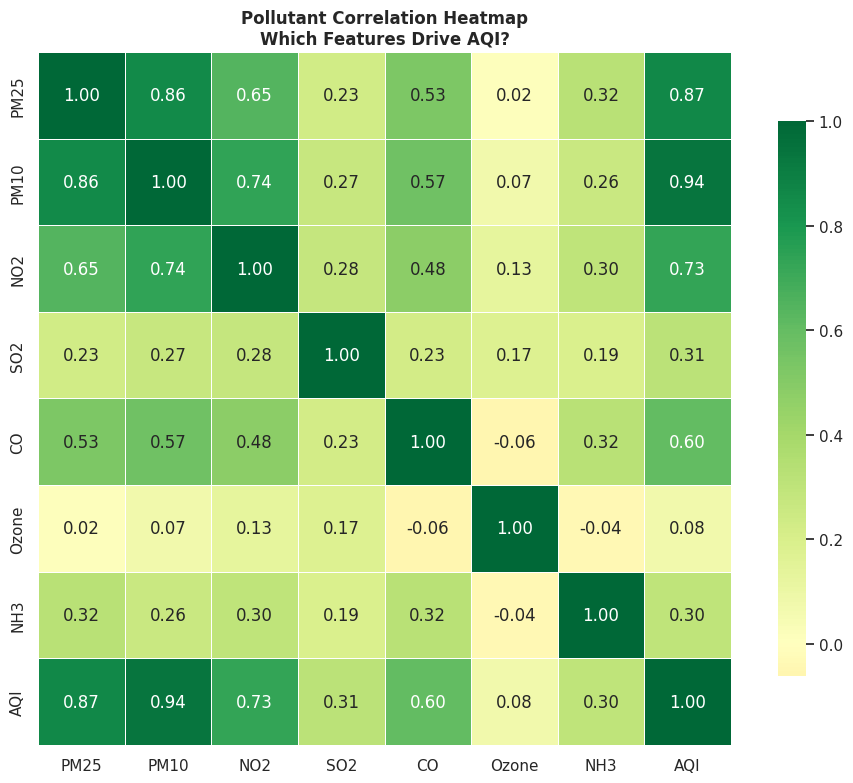

✅ Plot 4 saved!


In [44]:
# Plot 4 - Pollutant Correlation Heatmap
# Question: Which pollutants drive AQI? Are any redundant?

feature_cols = ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'AQI']
corr_matrix = master_df[feature_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Pollutant Correlation Heatmap\nWhich Features Drive AQI?', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot4_Correlation_Heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved!")

Plot 4 — Key Insight ✅
PM10 (0.94) and PM25 (0.87) are the strongest AQI drivers. Ozone (0.08) is almost irrelevant. SO2 (0.31) and NH3 (0.30) are weak. This will guide our feature importance analysis later.

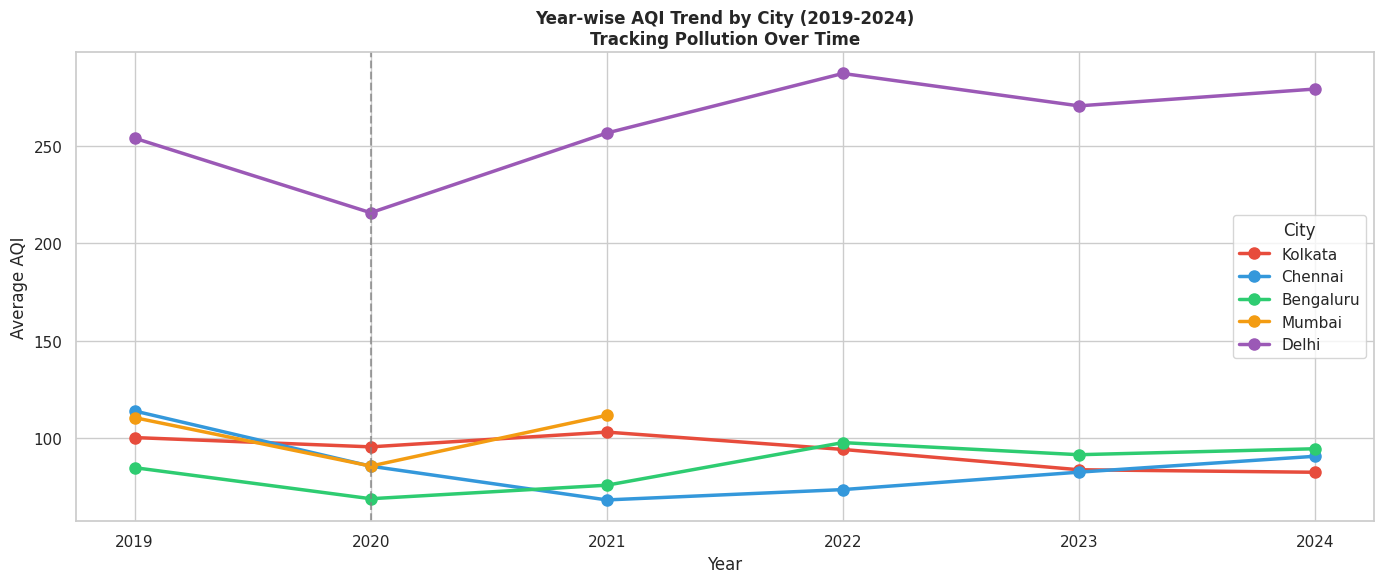

✅ Plot 5 saved!


In [45]:
# Plot 5 - City-wise AQI Over Years
# Question: Is pollution improving or worsening 2019-2024?

yearly_city_aqi = master_df.groupby(['Year', 'City'])['AQI'].mean().reset_index()

plt.figure(figsize=(14, 6))
for city, color in zip(cities, city_colors):
    data = yearly_city_aqi[yearly_city_aqi['City'] == city]
    plt.plot(data['Year'], data['AQI'], marker='o', label=city,
             color=color, linewidth=2.5, markersize=8)

plt.title('Year-wise AQI Trend by City (2019-2024)\nTracking Pollution Over Time',
          fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(range(2019, 2025))
plt.legend(title='City')
plt.axvline(x=2020, color='gray', linestyle='--', alpha=0.7, label='COVID Lockdown')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot5_Yearly_Trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved!")

Plot 5 — COVID Visible ✅
Delhi drops clearly in 2020 — the COVID lockdown signature is right there in the data!

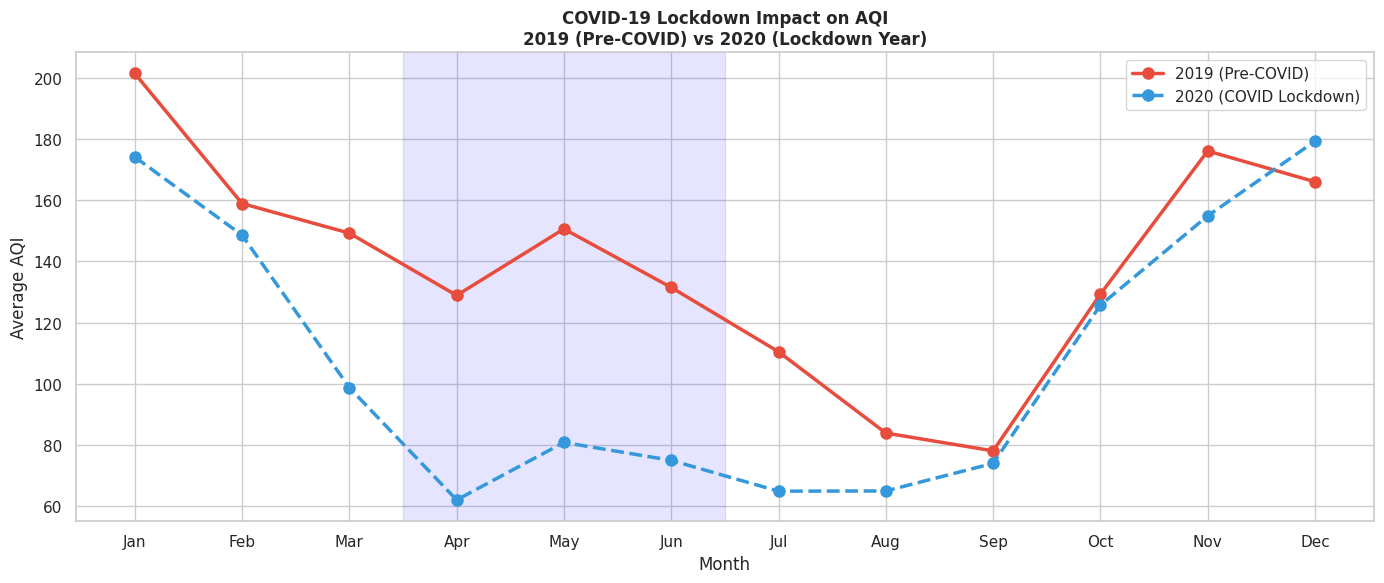

✅ Plot 6 saved!


In [48]:
# Plot 6 - COVID Lockdown Impact
# Question: Did the 2020 lockdown visibly reduce pollution?

covid_data = master_df[master_df['Year'].isin([2019, 2020])]
covid_monthly = covid_data.groupby(['Year', 'Month'])['AQI'].mean().reset_index()

plt.figure(figsize=(14, 6))
for year, color, style in zip([2019, 2020], ['#e74c3c', '#3498db'], ['-', '--']):
    data = covid_monthly[covid_monthly['Year'] == year]
    plt.plot(data['Month'], data['AQI'], marker='o',
             label=f'{year} {"(Pre-COVID)" if year==2019 else "(COVID Lockdown)"}',
             color=color, linewidth=2.5, linestyle=style, markersize=8)

plt.xticks(range(1, 13), month_names)
plt.title('COVID-19 Lockdown Impact on AQI\n2019 (Pre-COVID) vs 2020 (Lockdown Year)',
          fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.legend()
plt.axvspan(3.5, 6.5, alpha=0.1, color='blue', label='Peak Lockdown Period')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot6_COVID_Impact.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 6 saved!")

Look at April 2020 — AQI drops to ~62 while April 2019 was ~130.
That's nearly a 50% reduction in pollution during peak lockdown (Apr-Jun 2020) — exactly when India had its strictest lockdown. The blue dashed line stays consistently below the red line throughout the entire lockdown period.